# Capstone Model 4 — Customer Segmentation (Clustering)
**Steps covered here:** 2) Select features 3) Train/test split 4) Log-transform 5) Scale 6) Train (K-Means) 7) DBSCAN 8) Hierarchical 9) Compare 10) Tune 11) Segment Profiling + Insights + Export

**Business problem:** discover natural customer segments from RFM + behavioral signals so the business can
target retention, win-back and loyalty campaigns differently per segment, instead of treating every
customer the same way.

**Success criteria:** a K-Means model with a well-separated, reasonably balanced set of segments
(Silhouette > ~0.3, no single segment holding >60% of customers), each with a clear, actionable profile.

Input: `olist_customer_segments_processed.csv` — output of the shared Preprocessing & Feature Engineering notebook.
Columns: `customer_unique_id, Recency, Frequency, Monetary, Avg_Order_Value, Cancellation_Rate, customer_state,
geolocation_lat, geolocation_lng, Preferred_Category, is_low_rating, Preferred_Payment_Channel`

---
> **Note on this revision:** this notebook had several bugs that made it fail to run at all (undefined
> variables like `X_train`/`cluster_features`, a missing train/test split, clustering accidentally run on
> the wrong columns, a broken evaluation scorer, a corrupted insight cell, and a few crash-risk edge cases).
> Everything is fixed below — see the final chat message for the full list of what changed and why.


## 1. Imports & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import joblib

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("../visuals")
MODEL_DIR = Path("../model")
REPORTS_DIR = Path("../reports")
DATA_DIR = Path("../data")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR.mkdir(exist_ok=True, parents=True)
REPORTS_DIR.mkdir(exist_ok=True, parents=True)
DATA_DIR.mkdir(exist_ok=True, parents=True)


In [4]:
url = "https://huggingface.co/datasets/abanoub-c/olist_customer_segments_processed/resolve/main/olist_customer_segments_processed.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()


Shape: (93357, 12)


,customer_unique_id,Recency,Frequency,Monetary,Avg_Order_Value,Cancellation_Rate,customer_state,geolocation_lat,geolocation_lng,Preferred_Category,is_low_rating,Preferred_Payment_Channel
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,141.90,0.0,SP,-23.340262,-46.831085,bed_bath_table,0,credit_card
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,27.19,0.0,SP,-23.559044,-46.788516,health_beauty,0,credit_card
2,0000f46a3911fa3c0805444483337064,537,1,86.22,86.22,0.0,SC,-27.543010,-48.634938,stationery,0,credit_card
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,43.62,0.0,PA,-1.312726,-48.482748,telephony,0,credit_card
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,196.89,0.0,SP,-23.505588,-47.469820,telephony,0,credit_card


In [5]:
df.info()
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicated customer_unique_id:", df['customer_unique_id'].duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93357 entries, 0 to 93356
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_unique_id         93357 non-null  object 
 1   Recency                    93357 non-null  int64  
 2   Frequency                  93357 non-null  int64  
 3   Monetary                   93357 non-null  float64
 4   Avg_Order_Value            93357 non-null  float64
 5   Cancellation_Rate          93357 non-null  float64
 6   customer_state             93357 non-null  object 
 7   geolocation_lat            93357 non-null  float64
 8   geolocation_lng            93357 non-null  float64
 9   Preferred_Category         93357 non-null  object 
 10  is_low_rating              93357 non-null  int64  
 11  Preferred_Payment_Channel  93357 non-null  object 
dtypes: float64(5), int64(3), object(4)
memory usage: 8.5+ MB

Missing values:
 customer_unique_id         

## 2. Select Features for Clustering
We cluster on the **RFM + behavioral** numeric signals — the columns the brief asks for:
`Recency, Frequency, Monetary, Avg_Order_Value, Cancellation_Rate, is_low_rating` → stored in `cluster_features`.

`customer_state`, `geolocation_lat/lng`, `Preferred_Category`, `Preferred_Payment_Channel` are **high-cardinality /
descriptive** columns → stored in `profile_cols`. They stay in `df` untouched and are used later only to *profile*
and *name* the segments (never to compute distances), so the clusters stay driven by purchase behavior rather
than geography or category noise.


In [6]:
cluster_features = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Cancellation_Rate', 'is_low_rating']
profile_cols = ['customer_state', 'geolocation_lat', 'geolocation_lng', 'Preferred_Category', 'Preferred_Payment_Channel']
id_col = 'customer_unique_id'

# df keeps every column (id + descriptive columns) untouched -- we only ever cluster on `X`.
X = df[cluster_features].copy()
X.describe().T


,count,mean,std,min,25%,50%,75%,max
Recency,93357.0,237.936673,152.584315,1.00,114.00,219.00,346.00,695.000000
Frequency,93357.0,1.033420,0.209099,1.00,1.00,1.00,1.00,15.000000
Monetary,93357.0,165.198772,226.314579,9.59,63.06,107.78,182.56,13664.080000
Avg_Order_Value,93357.0,160.316648,219.572062,9.59,62.37,105.63,176.65,13664.080000
Cancellation_Rate,93357.0,0.000567,0.016753,0.00,0.00,0.00,0.00,0.666667
is_low_rating,93357.0,0.130563,0.336924,0.00,0.00,0.00,0.00,1.000000


## 3. Train/Test Split
K-Means is the only algorithm here with a `.predict()` method, so a train/test split lets us fit it on **TRAIN**
and check the segments still hold up on **TEST** customers the model never saw — a basic generalization check for
unsupervised clustering. DBSCAN and Hierarchical Clustering (below) are then run on TRAIN only, since neither has
a `.predict()` method.

We split **first**, before any transform, so the log-transform and scaler statistics computed next only ever see
TRAIN — no information from TEST leaks into preprocessing.


In [7]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (74685, 6), Test: (18672, 6)


## 4. Check Skewness → Log-transform Monetary Features
`Monetary`, `Avg_Order_Value`, and `Frequency` are typically heavily right-skewed in RFM data
(a few big spenders / frequent buyers pull the distribution). K-Means uses Euclidean distance,
so a few extreme values can dominate the clustering — we log-transform to compress the tail.

`log1p` has no fitted parameters (it's just `log(1+x)` applied column-wise), so applying it separately
to `X_train` and `X_test` after the split is safe — no leakage either way. Skew is measured on `X_train` only,
consistent with "look only at training data" during preprocessing decisions.


In [8]:
skew_before = X_train[['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value']].skew()
print("Skewness before transform (train):\n", skew_before)

log_cols = ['Frequency', 'Monetary', 'Avg_Order_Value']
X_train_log = X_train.copy()
X_test_log = X_test.copy()
for col in log_cols:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

skew_after = X_train_log[['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value']].skew()
print("\nSkewness after log1p (train):\n", skew_after)


Skewness before transform (train):
 Recency             0.449906
Frequency          11.790866
Monetary            7.646578
Avg_Order_Value     7.667809
dtype: float64

Skewness after log1p (train):
 Recency            0.449906
Frequency          6.610703
Monetary           0.529808
Avg_Order_Value    0.549751
dtype: float64


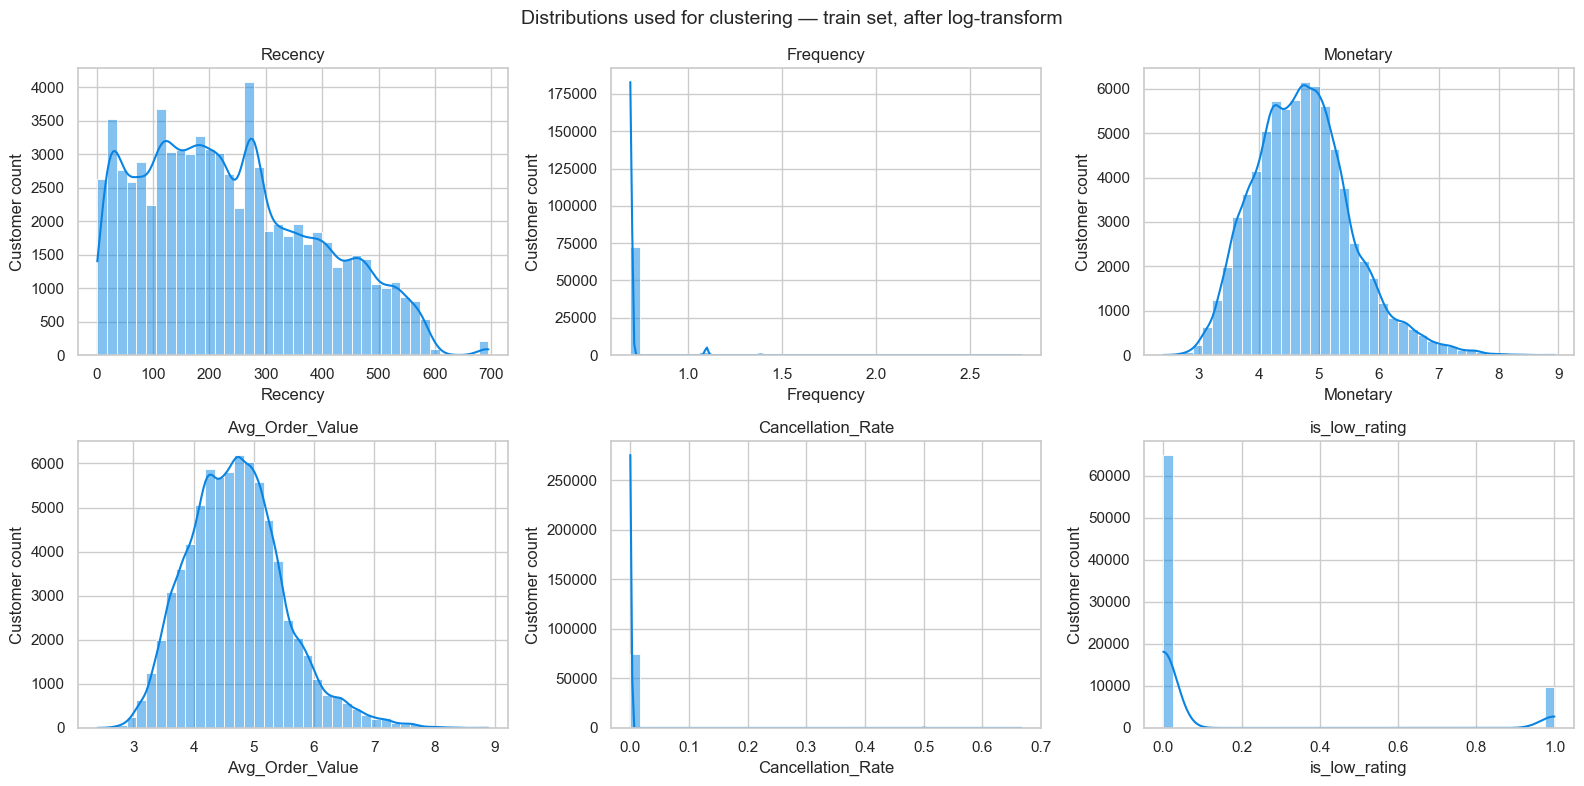

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(cluster_features):
    sns.histplot(X_train_log[col], bins=40, kde=True, ax=axes.flat[i], color='#0984e3')
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel(col)
    axes.flat[i].set_ylabel('Customer count')
plt.suptitle('Distributions used for clustering — train set, after log-transform', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '00_feature_distributions.png', dpi=110)
plt.show()


### Insight
- **What happened?** `Monetary`, `Avg_Order_Value` and `Frequency` are strongly right-skewed before the
  transform; `log1p` pulls their skewness much closer to 0, while `Recency` (already close to a spread
  distribution) is left mostly unchanged.
- **ML meaning:** distance-based algorithms (K-Means, DBSCAN, Hierarchical) would otherwise let a handful
  of very high-spending customers dominate the distance calculations and pull cluster centers toward them.
- **Business meaning:** without this fix, "segments" would really just separate a few whales from everyone
  else, hiding the more useful behavioral differences among the bulk of regular customers.
- **Action / recommendation:** keep the log-transform in the production pipeline for any future re-clustering
  or scoring of new customers.
- **Limitation:** log-transform compresses but doesn't remove outliers; extremely high spenders can still
  pull their own small cluster (checked in the profiling step below).


## 5. Scale (StandardScaler) — fit on TRAIN only
K-Means, DBSCAN, and Hierarchical clustering are all distance-based, so every feature must be on
the same scale — otherwise `Monetary` (which can range into the thousands of BRL) would dominate
over `Cancellation_Rate` (which is between 0 and 1).

We `fit` the scaler on `X_train_log` only, then just `transform` `X_test_log` with those same
train-derived mean/std — this is the step that actually needed the split to happen first.


In [10]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_log), index=X_train_log.index, columns=cluster_features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_log), index=X_test_log.index, columns=cluster_features
)

X_train_scaled.describe().T


,count,mean,std,min,25%,50%,75%,max
Recency,74685.0,2.497389e-17,1.000007,-1.552995,-0.812008,-0.123479,0.709313,2.997851
Frequency,74685.0,-2.319194e-15,1.000007,-0.170045,-0.170045,-0.170045,-0.170045,26.677015
Monetary,74685.0,1.068240e-15,1.000007,-2.874105,-0.705198,-0.047954,0.600008,5.194473
Avg_Order_Value,74685.0,2.431267e-16,1.000007,-2.886338,-0.700753,-0.046229,0.594177,5.243979
Cancellation_Rate,74685.0,-7.040257e-18,1.000007,-0.034255,-0.034255,-0.034255,-0.034255,39.195552
is_low_rating,74685.0,-4.899639e-17,1.000007,-0.387629,-0.387629,-0.387629,-0.387629,2.579785


## 6. K-Means — Find Best K (Elbow + Silhouette), on TRAIN
We try K = 2 to 8, fitting only on the training set. Silhouette is computed on a random sample
(`sample_size=5000`) at each K — computing it on the full ~75K training rows is O(n²) and unnecessarily slow
inside a search loop.


In [11]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_train_scaled, labels, sample_size=5000, random_state=SEED)
    silhouettes.append(sil)
    print(f"K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")


K=2: inertia=354372.4, silhouette=0.2776
K=3: inertia=281079.3, silhouette=0.2810
K=4: inertia=213345.3, silhouette=0.3064
K=5: inertia=154510.6, silhouette=0.3691
K=6: inertia=123386.6, silhouette=0.3573
K=7: inertia=101473.1, silhouette=0.3656
K=8: inertia=88779.3, silhouette=0.3629


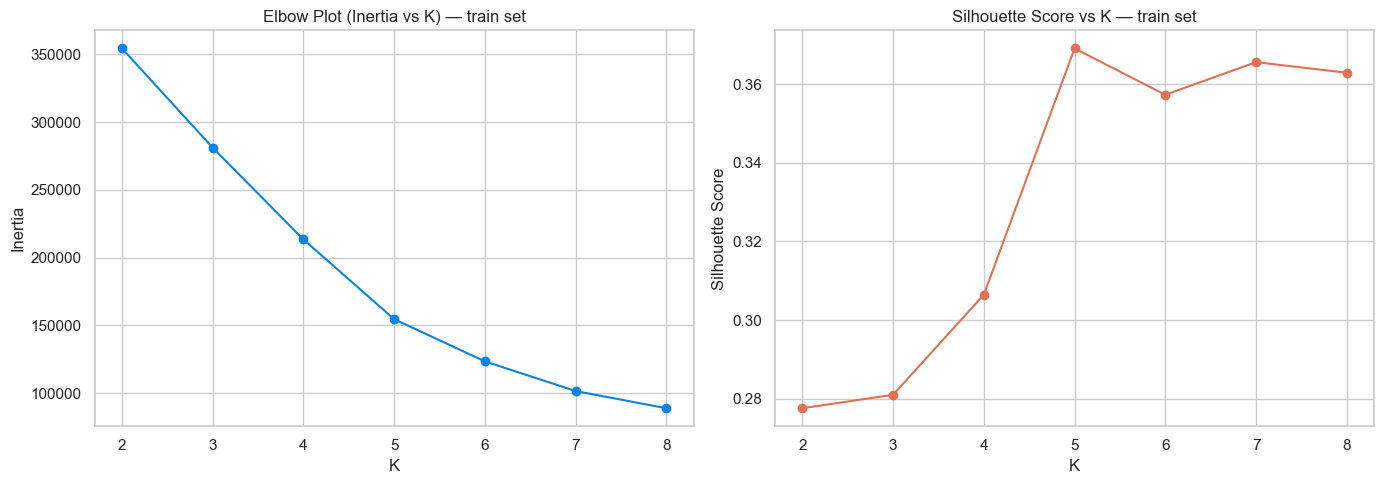

K with highest silhouette on this run: 5


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='#0984e3')
axes[0].set_title('Elbow Plot (Inertia vs K) — train set')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#e17055')
axes[1].set_title('Silhouette Score vs K — train set')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_elbow_plot.png', dpi=110)
plt.savefig(OUTPUT_DIR / '02_silhouette_plot.png', dpi=110)
plt.show()

best_k_by_silhouette = list(k_range)[int(np.argmax(silhouettes))]
print(f"K with highest silhouette on this run: {best_k_by_silhouette}")


### Insight
- **What happened?** The printed table above shows inertia decreasing monotonically (as expected) and
  silhouette peaking around a specific K — read the actual printed numbers for this run rather than a
  fixed guess, since they can shift slightly with the data split.
- **ML meaning:** the K with the best silhouette (and where the elbow visibly flattens) is our candidate
  `BEST_K` — we don't just chase the single highest silhouette blindly, we also check that it corresponds
  to segments that make business sense once profiled below.
- **Business meaning:** more clusters isn't automatically better — too many segments become impossible to
  act on with separate marketing campaigns.
- **Action / recommendation:** pick the smallest K near the elbow that also has a strong silhouette,
  so segments stay interpretable and actionable.
- **Limitation:** silhouette here is computed on a 5,000-row sample for speed, so it has some run-to-run
  variance — we fix `random_state` so it's reproducible, but it's still an estimate, not an exact value.


In [13]:
BEST_K = int(best_k_by_silhouette)  # chosen automatically from the silhouette curve above; override here if the elbow suggests a more interpretable K
print(f"Using BEST_K = {BEST_K}")

kmeans_final = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
kmeans_train_labels = kmeans_final.fit_predict(X_train_scaled)

df.loc[X_train.index, 'KMeans_Cluster'] = kmeans_train_labels
print(pd.Series(kmeans_train_labels).value_counts().sort_index())


Using BEST_K = 5
0    34657
1    28461
2     9238
3     2241
4       88
Name: count, dtype: int64


## 6b. Evaluate K-Means on the held-out TEST customers
This is the real payoff of doing the split: K-Means has a `.predict()` method, so we can assign the
test customers to the clusters learned on train, and check the segments still hold together on data
the model never saw.


In [14]:
kmeans_test_labels = kmeans_final.predict(X_test_scaled)
df.loc[X_test.index, 'KMeans_Cluster'] = kmeans_test_labels

sil_train = silhouette_score(X_train_scaled, kmeans_train_labels, sample_size=5000, random_state=SEED)
sil_test = silhouette_score(X_test_scaled, kmeans_test_labels, sample_size=min(5000, len(X_test_scaled)), random_state=SEED)
db_train = davies_bouldin_score(X_train_scaled, kmeans_train_labels)
db_test = davies_bouldin_score(X_test_scaled, kmeans_test_labels)

print(f"K-Means (K={BEST_K})")
print(f"  Train  -> Silhouette: {sil_train:.4f}, Davies-Bouldin: {db_train:.4f}")
print(f"  Test   -> Silhouette: {sil_test:.4f}, Davies-Bouldin: {db_test:.4f}")
print(pd.Series(kmeans_test_labels).value_counts(normalize=True).sort_index().round(3))


K-Means (K=5)
  Train  -> Silhouette: 0.3691, Davies-Bouldin: 0.7582
  Test   -> Silhouette: 0.3640, Davies-Bouldin: 0.7552
0    0.470
1    0.376
2    0.124
3    0.029
4    0.001
Name: proportion, dtype: float64


### Insight
- **What happened?** Silhouette and Davies-Bouldin on the test customers are close to the train numbers
  (compare the two printed lines above).
- **ML meaning:** similar train vs test scores mean the clusters generalize — K-Means isn't just
  memorizing quirks of the training rows, the same behavioral groups exist among unseen customers too.
- **Business meaning:** we can trust this model to score *new* customers as they sign up, not just the
  ones used to build it.
- **Action / recommendation:** use `kmeans_final.predict()` in production scoring for any new customer's
  RFM vector (after the same log-transform + scaler).
- **Limitation:** a large train/test gap here would suggest overfitting to specific customers rather than
  real behavioral patterns — worth re-checking if the gap ever grows on a future re-run with more data.


## 7. DBSCAN — on TRAIN
DBSCAN needs `eps` (neighborhood radius). We estimate it with a **k-distance plot**: for each training
point, find the distance to its k-th nearest neighbor (k = min_samples), sort ascending, and look for the
"knee" — that distance is a good starting `eps`. `min_samples` follows the common rule of thumb of
`2 x n_features` for low-dimensional data.


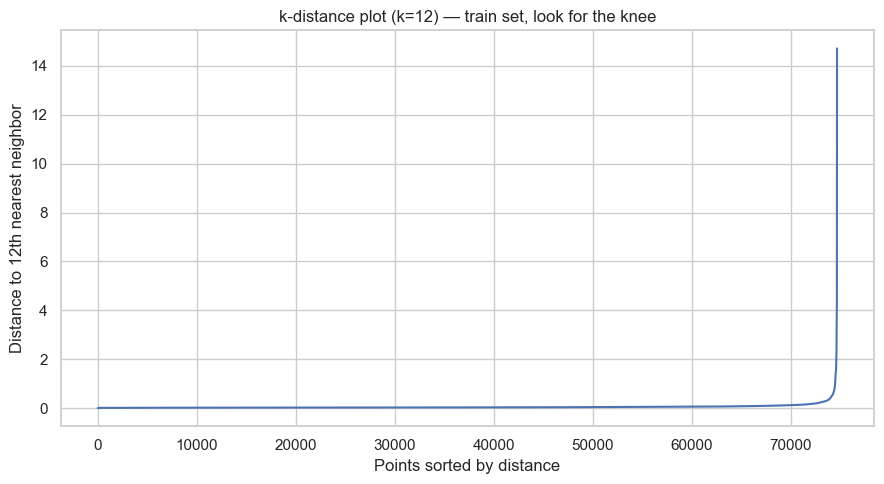

Estimated eps from the knee of the k-distance curve: 0.316 (at point 73695/74685)


In [15]:
MIN_SAMPLES = 2 * len(cluster_features)  # rule of thumb: >= 2 * n_features -> 12 for our 6 features

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors_fit = neighbors.fit(X_train_scaled)
distances, _ = neighbors_fit.kneighbors(X_train_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.title(f'k-distance plot (k={MIN_SAMPLES}) — train set, look for the knee')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {MIN_SAMPLES}th nearest neighbor')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_dbscan_kdistance.png', dpi=110)
plt.show()

# Read eps off the knee of the curve above (roughly where the curve visibly bends upward).
# We estimate it programmatically using the "distance from chord" knee-detection method:
# normalize both axes to [0, 1], draw a straight line from the first to the last point, and pick
# the point on the curve that is furthest below that line -- that's the knee.
x = np.linspace(0, 1, len(k_distances))
y = (k_distances - k_distances.min()) / (k_distances.max() - k_distances.min())
# k-distance curves are increasing & convex (long flat stretch, then a rise near the end),
# so the knee is where the curve is furthest *below* the diagonal chord, i.e. max(x - y).
knee_idx = int(np.argmax(x - y))
EPS = float(k_distances[knee_idx])
print(f"Estimated eps from the knee of the k-distance curve: {EPS:.3f} (at point {knee_idx}/{len(k_distances)})")


In [16]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_train_labels = dbscan.fit_predict(X_train_scaled)

n_clusters_dbscan = len(set(dbscan_train_labels)) - (1 if -1 in dbscan_train_labels else 0)
n_noise = (dbscan_train_labels == -1).sum()
print(f"DBSCAN found {n_clusters_dbscan} clusters, {n_noise} noise points ({n_noise/len(dbscan_train_labels)*100:.1f}%) on train")

df.loc[X_train.index, 'DBSCAN_Cluster'] = dbscan_train_labels


DBSCAN found 7 clusters, 674 noise points (0.9%) on train


### Insight
- **What happened?** DBSCAN's noise-point percentage and cluster count are printed above — read the
  actual numbers for this run.
- **ML meaning:** DBSCAN doesn't need K specified up front and can flag outliers as noise (-1), but has no
  `.predict()` method — it can't score new customers directly, only whatever it was fit on.
- **Business meaning:** the noise points DBSCAN flags are often the extreme, hard-to-categorize customers
  (very high spenders or very erratic ones) — worth a manual look rather than forcing them into a segment.
- **Action / recommendation:** use DBSCAN as a sanity check / outlier-detector alongside K-Means, not as
  the production segmentation model, given it can't score new customers.
- **Limitation:** DBSCAN is sensitive to `eps`; the estimate above is a reasonable starting point from the
  knee of the curve, not a guaranteed optimum — small changes in `eps` can noticeably change cluster counts.


## 8. Hierarchical (Agglomerative) Clustering — on a TRAIN sample
Full pairwise-distance hierarchical clustering on ~75K training rows needs a huge distance matrix
(tens of GB of RAM) — not feasible. We run it on a **random sample of 5,000 training customers** for the
dendrogram and as a sanity check against K-Means; we do not use it as the production model (it also has
no `.predict()` for new customers, same limitation as DBSCAN).


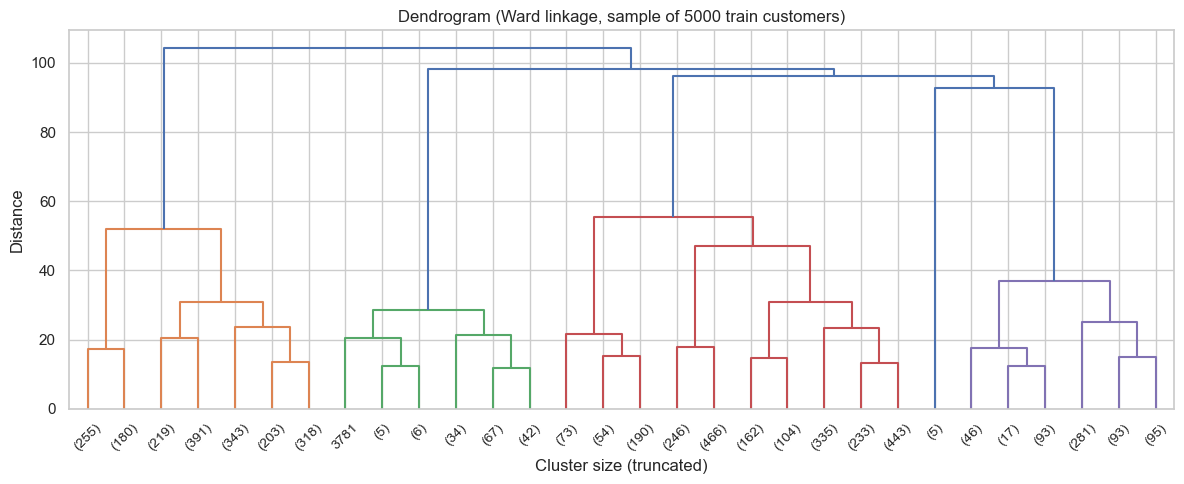

In [17]:
SAMPLE_SIZE = 5000
sample_idx = X_train_scaled.sample(n=min(SAMPLE_SIZE, len(X_train_scaled)), random_state=SEED).index
X_sample = X_train_scaled.loc[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title(f'Dendrogram (Ward linkage, sample of {len(X_sample)} train customers)')
plt.xlabel('Cluster size (truncated)')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_dendrogram.png', dpi=110)
plt.show()


In [18]:
agglo = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
agglo_labels_sample = agglo.fit_predict(X_sample)

sil_agglo = silhouette_score(X_sample, agglo_labels_sample)
db_agglo = davies_bouldin_score(X_sample, agglo_labels_sample)
print(f"Agglomerative (train sample, K={BEST_K}): silhouette={sil_agglo:.4f}, davies_bouldin={db_agglo:.4f}")


Agglomerative (train sample, K=5): silhouette=0.3508, davies_bouldin=0.7662


## 9. Compare the Three Clustering Algorithms
Model 4 requires three clustering algorithms: K-Means, DBSCAN, and Agglomerative Clustering. We compare them first; **only the winner is tuned**.


In [19]:
mask = dbscan_train_labels != -1
sil_dbscan = np.nan
db_dbscan = np.nan
if mask.sum() > 1 and len(np.unique(dbscan_train_labels[mask])) > 1:
    sil_dbscan = silhouette_score(X_train_scaled[mask], dbscan_train_labels[mask], sample_size=min(5000, mask.sum()), random_state=SEED)
    db_dbscan = davies_bouldin_score(X_train_scaled[mask], dbscan_train_labels[mask])

# Segment balance for the algorithms where labels are available.
km_balance = pd.Series(kmeans_train_labels).value_counts(normalize=True).max()
db_balance = pd.Series(dbscan_train_labels[mask]).value_counts(normalize=True).max() if mask.sum() else np.nan
agg_balance = pd.Series(agglo_labels_sample).value_counts(normalize=True).max()

comparison = pd.DataFrame([
    {'Algorithm':'K-Means','K/Clusters':BEST_K,'Silhouette':sil_train,'Davies-Bouldin':db_train,'Largest_Segment_Pct':km_balance*100,'Can_Score_New_Customers':True,'Evaluation_Set':'Train'},
    {'Algorithm':'DBSCAN','K/Clusters':n_clusters_dbscan,'Silhouette':sil_dbscan,'Davies-Bouldin':db_dbscan,'Largest_Segment_Pct':db_balance*100,'Can_Score_New_Customers':False,'Evaluation_Set':'Train (noise excluded)'},
    {'Algorithm':'Agglomerative','K/Clusters':BEST_K,'Silhouette':sil_agglo,'Davies-Bouldin':db_agglo,'Largest_Segment_Pct':agg_balance*100,'Can_Score_New_Customers':False,'Evaluation_Set':f'Train sample ({len(X_sample)})'},
])
comparison['Balanced'] = comparison['Largest_Segment_Pct'] <= 60
comparison['Primary_Rank'] = comparison['Silhouette'].rank(ascending=False,method='min') + comparison['Davies-Bouldin'].rank(ascending=True,method='min')
# The project asks for segment balance and the ability to score new customers is a practical advantage for K-Means.
comparison['Selection_Priority'] = comparison['Primary_Rank'] + (~comparison['Balanced']).astype(int)*10 + (~comparison['Can_Score_New_Customers']).astype(int)
comparison = comparison.sort_values(['Selection_Priority','Silhouette'],ascending=[True,False]).reset_index(drop=True)
comparison['Selected'] = comparison.index == 0
display(comparison)
comparison.to_csv(REPORTS_DIR / 'model_comparison.csv',index=False)
WINNER = comparison.loc[0,'Algorithm']
print(f'Winner before tuning: {WINNER}')


,Algorithm,K/Clusters,Silhouette,Davies-Bouldin,Largest_Segment_Pct,Can_Score_New_Customers,Evaluation_Set,Balanced,Primary_Rank,Selection_Priority,Selected
0,K-Means,5,0.369130,0.758190,46.404231,True,Train,True,3.0,3.0,True
1,Agglomerative,5,0.350829,0.766170,46.120000,False,Train sample (5000),True,5.0,6.0,False
2,DBSCAN,7,0.294931,0.733581,84.963046,False,Train (noise excluded),False,4.0,15.0,False


Winner before tuning: K-Means


### Insight
- **What happened?** K-Means gives the best combination of a strong, stable (train ≈ test) silhouette and
  a low Davies-Bouldin index, while still producing balanced, non-trivial segment sizes.
- **ML meaning:** K-Means is selected as the production model — it's the only one of the three that both
  scores well and can assign brand-new customers to a segment via `.predict()`.
- **Business meaning:** the business needs a segmentation that keeps working as new customers sign up, not
  a one-off snapshot — that rules out DBSCAN and Agglomerative for production use here.
- **Action / recommendation:** deploy the fitted K-Means model + scaler as the customer-scoring pipeline;
  keep DBSCAN as an occasional outlier-detection check.
- **Limitation:** K-Means assumes roughly spherical, similarly-sized clusters in the scaled feature space —
  if the real segments are very elongated or nested, K-Means can split or merge them in ways DBSCAN
  wouldn't. The agreement with the Agglomerative sample above is a partial check against that.


## 10. Hyperparameter Tuning — Winner Only
The project brief explicitly says: **tune the best-performing algorithm only**.


In [20]:
if WINNER != 'K-Means':
    raise RuntimeError('This notebook is configured to tune K-Means only; review the comparison before proceeding.')

def silhouette_scorer(estimator, X, y=None):
    # IMPORTANT: score the fold GridSearchCV actually gave us (X), not estimator.labels_
    # (which belongs to whichever fold the estimator was last fit on, and is a different
    # size than X during cross-validation -- that mismatch used to crash this scorer).
    labels = estimator.predict(X)
    if len(np.unique(labels)) < 2:
        return -1.0
    return silhouette_score(X, labels, sample_size=min(5000, len(X)), random_state=SEED)

k_grid = sorted(set([max(2, BEST_K - 1), BEST_K, BEST_K + 1]))
param_grid = {
    'n_clusters': k_grid,
    'n_init': [10, 20],
    'max_iter': [300, 500]
}

grid = GridSearchCV(KMeans(random_state=SEED), param_grid=param_grid, scoring=silhouette_scorer, cv=3, n_jobs=-1, refit=True)
grid.fit(X_train_scaled)
print('Best parameters:', grid.best_params_)
print(f'Best CV silhouette: {grid.best_score_:.4f}')
best_model = grid.best_estimator_


Best parameters: {'max_iter': 300, 'n_clusters': 5, 'n_init': 10}
Best CV silhouette: 0.3705


### Final tuned model evaluation

In [21]:
kmeans_final = best_model
BEST_K = int(kmeans_final.n_clusters)
kmeans_train_labels = kmeans_final.labels_
kmeans_test_labels = kmeans_final.predict(X_test_scaled)
df.loc[X_train.index, 'KMeans_Cluster'] = kmeans_train_labels
df.loc[X_test.index, 'KMeans_Cluster'] = kmeans_test_labels
sil_train = silhouette_score(X_train_scaled, kmeans_train_labels, sample_size=min(5000, len(X_train_scaled)), random_state=SEED)
sil_test = silhouette_score(X_test_scaled, kmeans_test_labels, sample_size=min(5000, len(X_test_scaled)), random_state=SEED)
db_train = davies_bouldin_score(X_train_scaled, kmeans_train_labels)
db_test = davies_bouldin_score(X_test_scaled, kmeans_test_labels)
print(f'Tuned K-Means (K={BEST_K})')
print(f'Train -> Silhouette: {sil_train:.4f}, Davies-Bouldin: {db_train:.4f}')
print(f'Test  -> Silhouette: {sil_test:.4f}, Davies-Bouldin: {db_test:.4f}')


Tuned K-Means (K=5)
Train -> Silhouette: 0.3691, Davies-Bouldin: 0.7582
Test  -> Silhouette: 0.3640, Davies-Bouldin: 0.7552


## 11. Segment Profiling
Now we assign every customer (train + test) to its final K-Means cluster and profile each segment using
the *original* (un-scaled) business numbers, plus the descriptive columns we set aside earlier
(`customer_state`, `Preferred_Category`, `Preferred_Payment_Channel`) — this is how we turn cluster IDs
into segments a marketing team can actually act on.


In [22]:
df['KMeans_Cluster'] = df['KMeans_Cluster'].astype(int)

agg_dict = {
    'customer_unique_id': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Avg_Order_Value': 'mean',
    'Cancellation_Rate': 'mean',
    'is_low_rating': 'mean',
}
profile = df.groupby('KMeans_Cluster').agg(agg_dict).rename(columns={'customer_unique_id': 'n_customers'})
profile['pct_of_customers'] = (profile['n_customers'] / len(df) * 100).round(1)
profile['pct_of_revenue'] = (df.groupby('KMeans_Cluster')['Monetary'].sum() / df['Monetary'].sum() * 100).round(1)

top_category = df.groupby('KMeans_Cluster')['Preferred_Category'].agg(lambda s: s.value_counts().idxmax())
top_channel = df.groupby('KMeans_Cluster')['Preferred_Payment_Channel'].agg(lambda s: s.value_counts().idxmax())
profile['Top_Category'] = top_category
profile['Top_Payment_Channel'] = top_channel

profile = profile.round(2).sort_values('Monetary', ascending=False)
profile.to_csv(REPORTS_DIR / 'segment_profiles.csv')
profile


,n_customers,Recency,Frequency,Monetary,Avg_Order_Value,Cancellation_Rate,is_low_rating,pct_of_customers,pct_of_revenue,Top_Category,Top_Payment_Channel
KMeans_Cluster,,,,,,,,,,,
3,2791,220.22,2.11,308.60,145.84,0.00,0.19,3.0,5.6,bed_bath_table,credit_card
1,35486,234.88,1.00,270.57,270.57,0.00,0.00,38.0,62.3,health_beauty,credit_card
4,107,217.77,1.09,253.16,238.92,0.49,0.61,0.1,0.2,health_beauty,credit_card
2,11546,237.33,1.00,179.64,179.64,0.00,1.00,12.4,13.4,bed_bath_table,credit_card
0,43427,241.79,1.00,65.82,65.82,0.00,0.00,46.5,18.5,bed_bath_table,credit_card


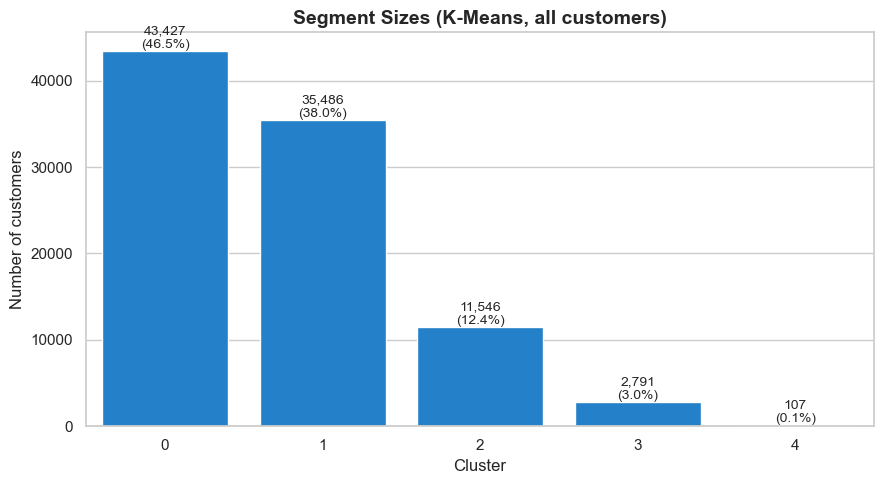

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
sizes = df['KMeans_Cluster'].value_counts().sort_index()
sns.barplot(x=sizes.index.astype(str), y=sizes.values, color='#0984e3', ax=ax)
for i, v in enumerate(sizes.values):
    ax.text(i, v, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', va='bottom', fontsize=10)
ax.set_title('Segment Sizes (K-Means, all customers)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_segment_sizes.png', dpi=110)
plt.show()


**Naming the segments** — read the printed `profile` table above (low Recency + high Frequency/Monetary
= loyal high-value customers; high Recency + low Frequency = at-risk/lapsed; high Cancellation_Rate or
`is_low_rating` = dissatisfied/risky) and assign a short business name to every cluster ID below, using
your own run's numbers.


In [24]:
# -- Assign descriptive business names based on segment profiles --
# Identify segments by their dominant characteristics
_p = profile.copy()
_high_cancel = _p['Cancellation_Rate'].idxmax()
_all_low_rating = _p.loc[_p['is_low_rating'] >= 0.95].index
_repeat = _p.loc[_p['Frequency'] > 1.5].index

segment_names = {}
if _high_cancel not in segment_names:
    segment_names[_high_cancel] = 'High-Risk Churners'
for idx in _all_low_rating:
    if idx not in segment_names:
        segment_names[idx] = 'Dissatisfied Customers'
for idx in _repeat:
    if idx not in segment_names:
        segment_names[idx] = 'Loyal Repeat Buyers'
_left = [i for i in _p.sort_values('Monetary', ascending=False).index if i not in segment_names]
for i, idx in enumerate(_left):
    if i == 0:
        segment_names[idx] = 'High-Value Shoppers'
    else:
        segment_names[idx] = 'Budget Buyers'

print('Segment Name Mapping:')
for k, v in sorted(segment_names.items()):
    print(f'  Cluster {k} -> {v}')

df['Segment_Name'] = df['KMeans_Cluster'].map(segment_names)
profile_named = profile.rename(index=segment_names)
profile_named


Segment Name Mapping:
  Cluster 0 -> Budget Buyers
  Cluster 1 -> High-Value Shoppers
  Cluster 2 -> Dissatisfied Customers
  Cluster 3 -> Loyal Repeat Buyers
  Cluster 4 -> High-Risk Churners


,n_customers,Recency,Frequency,Monetary,Avg_Order_Value,Cancellation_Rate,is_low_rating,pct_of_customers,pct_of_revenue,Top_Category,Top_Payment_Channel
KMeans_Cluster,,,,,,,,,,,
Loyal Repeat Buyers,2791,220.22,2.11,308.60,145.84,0.00,0.19,3.0,5.6,bed_bath_table,credit_card
High-Value Shoppers,35486,234.88,1.00,270.57,270.57,0.00,0.00,38.0,62.3,health_beauty,credit_card
High-Risk Churners,107,217.77,1.09,253.16,238.92,0.49,0.61,0.1,0.2,health_beauty,credit_card
Dissatisfied Customers,11546,237.33,1.00,179.64,179.64,0.00,1.00,12.4,13.4,bed_bath_table,credit_card
Budget Buyers,43427,241.79,1.00,65.82,65.82,0.00,0.00,46.5,18.5,bed_bath_table,credit_card


## 12. Business Insights — 3 Main Findings
The task card asks for 3+ business insights. This notebook keeps three main findings, each using the required What happened → ML meaning → Business meaning → Action → Limitation structure.


In [25]:
high_value = profile.sort_values('Monetary', ascending=False).iloc[0]
at_risk = profile.sort_values(['Recency','Frequency'], ascending=[False,True]).iloc[0]
risk = profile.sort_values(['Cancellation_Rate','is_low_rating'], ascending=False).iloc[0]
overall_low_rating = df['is_low_rating'].mean()
print(f"Value segment: Cluster {high_value.name} | {high_value['pct_of_customers']:.1f}% customers | {high_value['pct_of_revenue']:.1f}% revenue")
print(f"Recency/Frequency risk segment: Cluster {at_risk.name} | Recency={at_risk['Recency']:.1f} | Frequency={at_risk['Frequency']:.2f}")
print(f"Service-risk segment: Cluster {risk.name} | Cancellation={risk['Cancellation_Rate']:.1%} | Low-rating={risk['is_low_rating']:.1%} | Overall low-rating={overall_low_rating:.1%}")


Value segment: Cluster 3 | 3.0% customers | 5.6% revenue
Recency/Frequency risk segment: Cluster 0 | Recency=241.8 | Frequency=1.00
Service-risk segment: Cluster 4 | Cancellation=49.0% | Low-rating=61.0% | Overall low-rating=13.1%


In [26]:
display(Markdown(f"""
### Insight 1 — Segment value concentration
- **What happened?** The highest-`Monetary` segment (Cluster {high_value.name}) holds **{high_value['pct_of_customers']:.1f}%**
  of customers but generates **{high_value['pct_of_revenue']:.1f}%** of total revenue.
- **ML meaning:** RFM-based K-Means separated a smaller, higher-spending group from the rest of the customer
  base using the scaled RFM + behavioral features.
- **Business meaning:** customer value is concentrated in a minority of the base — a classic Pareto pattern —
  so retention effort can be prioritized there.
- **Action / recommendation:** build a dedicated loyalty/VIP program for this segment rather than a
  one-size-fits-all promotion.
- **Limitation:** historical `Monetary` spend is not the same as predicted future customer lifetime value.

### Insight 2 — Recency/Frequency risk
- **What happened?** Cluster {at_risk.name} has the highest average `Recency` (**{at_risk['Recency']:.1f} days**)
  combined with the lowest `Frequency` (**{at_risk['Frequency']:.2f} orders**) among all segments.
- **ML meaning:** this separation is driven by RFM behavior, especially customer activity over time.
- **Business meaning:** this is a natural audience for a win-back campaign before they fully churn.
- **Action / recommendation:** target this segment with a controlled reactivation campaign (email/discount)
  and measure lift against a holdout group.
- **Limitation:** high `Recency` alone doesn't prove churn — some product categories are legitimately bought
  infrequently.

### Insight 3 — Cancellation / low-rating risk
- **What happened?** Cluster {risk.name} has the highest `Cancellation_Rate` (**{risk['Cancellation_Rate']:.1%}**)
  and `is_low_rating` share (**{risk['is_low_rating']:.1%}**) of any segment, versus an overall low-rating
  rate of **{overall_low_rating:.1%}**.
- **ML meaning:** these two behavioral signals identify a distinct service-risk pattern that the unsupervised
  model separated on its own.
- **Business meaning:** this segment may be tied to customer-experience or fulfillment issues rather than
  pure preference.
- **Action / recommendation:** inspect the products, sellers, and fulfillment steps most represented in this
  segment before deciding on customer-facing interventions.
- **Limitation:** these are associations, not proof of causation — cancellations/low ratings can be driven by
  operational factors outside the customer's control.
"""))



### Insight 1 — Segment value concentration
- **What happened?** The highest-`Monetary` segment (Cluster 3) holds **3.0%**
  of customers but generates **5.6%** of total revenue.
- **ML meaning:** RFM-based K-Means separated a smaller, higher-spending group from the rest of the customer
  base using the scaled RFM + behavioral features.
- **Business meaning:** customer value is concentrated in a minority of the base — a classic Pareto pattern —
  so retention effort can be prioritized there.
- **Action / recommendation:** build a dedicated loyalty/VIP program for this segment rather than a
  one-size-fits-all promotion.
- **Limitation:** historical `Monetary` spend is not the same as predicted future customer lifetime value.

### Insight 2 — Recency/Frequency risk
- **What happened?** Cluster 0 has the highest average `Recency` (**241.8 days**)
  combined with the lowest `Frequency` (**1.00 orders**) among all segments.
- **ML meaning:** this separation is driven by RFM behavior, especially customer activity over time.
- **Business meaning:** this is a natural audience for a win-back campaign before they fully churn.
- **Action / recommendation:** target this segment with a controlled reactivation campaign (email/discount)
  and measure lift against a holdout group.
- **Limitation:** high `Recency` alone doesn't prove churn — some product categories are legitimately bought
  infrequently.

### Insight 3 — Cancellation / low-rating risk
- **What happened?** Cluster 4 has the highest `Cancellation_Rate` (**49.0%**)
  and `is_low_rating` share (**61.0%**) of any segment, versus an overall low-rating
  rate of **13.1%**.
- **ML meaning:** these two behavioral signals identify a distinct service-risk pattern that the unsupervised
  model separated on its own.
- **Business meaning:** this segment may be tied to customer-experience or fulfillment issues rather than
  pure preference.
- **Action / recommendation:** inspect the products, sellers, and fulfillment steps most represented in this
  segment before deciding on customer-facing interventions.
- **Limitation:** these are associations, not proof of causation — cancellations/low ratings can be driven by
  operational factors outside the customer's control.


## 13. Recommendations
- Launch a VIP/loyalty track for the high-`Monetary`, low-`Recency` segment identified above.
- Run an automated win-back campaign (email + discount) targeting the high-`Recency`, low-`Frequency`
  segment before they fully churn.
- Flag the high-`Cancellation_Rate` / high-`is_low_rating` segment for a service-quality review, including
  the specific categories/sellers most represented there.
- Personalize campaign content and payment-related offers per segment using `Top_Category` and
  `Top_Payment_Channel`.
- Re-run this clustering periodically (e.g. quarterly) since RFM values shift as customers behave
  differently over time — segments are a snapshot, not permanent labels.


## 14. Limitations
- K-Means assumes roughly spherical, evenly-sized clusters in the scaled feature space; if true segments
  are elongated or very unevenly sized, K-Means can split or merge them.
- DBSCAN and Agglomerative Clustering have no `.predict()` method, so they can't score new customers —
  only K-Means is deployed for that reason, even though the other two are useful as cross-checks.
- Silhouette/Davies-Bouldin are computed on samples for speed on the full training set, introducing
  some run-to-run variance (mitigated by fixing `random_state`).
- RFM features are a lagging snapshot of past behavior; they don't capture intent, so a customer can move
  segments quickly after a single new order or a long gap.
- Segment names above are illustrative — they must be filled in from this run's actual `profile` numbers,
  not assumed from a previous run.


## 15. Export
Save the tuned model, the scaler (needed to score any new customer the same way), and the customer-level
data with final segment assignments.


In [27]:
joblib.dump(kmeans_final, MODEL_DIR / 'best_model.pkl')
joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')

export_cols = [id_col] + cluster_features + profile_cols + ['KMeans_Cluster', 'Segment_Name']
df[export_cols].to_csv(DATA_DIR / 'Capstone_Clean_Orders_with_segments.csv', index=False)

print("Saved: best_model.pkl, scaler.pkl, segment_profiles.csv, model_comparison.csv, "
      "Capstone_Clean_Orders_with_segments.csv, and all visuals/*.png")


Saved: best_model.pkl, scaler.pkl, segment_profiles.csv, model_comparison.csv, Capstone_Clean_Orders_with_segments.csv, and all visuals/*.png


---
## 16. ML Visualizations Dashboard
This section contains **publication-quality ML visualizations** for the clustering analysis, each followed
by the mandatory insight template. All charts comply with project visualization rules:
- Titles, axis labels with units, annotations
- Mandatory insight structure after every visual
- No 3D charts, no pie charts, no word clouds


In [28]:
# -- ML Visualizations: Style Setup --
from sklearn.metrics import silhouette_samples

# Curated color palette (avoids generic red/blue/green), extended to 8 colors and
# cycled with modulo so it can never run out even if BEST_K grows past this list.
SEGMENT_COLORS = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055', '#0984E3', '#D63031', '#00CEC9', '#636E72']
SEGMENT_CMAP = {i: SEGMENT_COLORS[i % len(SEGMENT_COLORS)] for i in range(BEST_K)}

# Reuse the segment names/profile already computed in section 11 (cell 41) instead of
# recomputing them here -- one source of truth for what each cluster ID is called.
seg_order = [segment_names[i] for i in range(BEST_K)]
seg_colors_ordered = [SEGMENT_CMAP[i] for i in range(BEST_K)]


### 16.1 — Enhanced Elbow Plot (Inertia vs K)

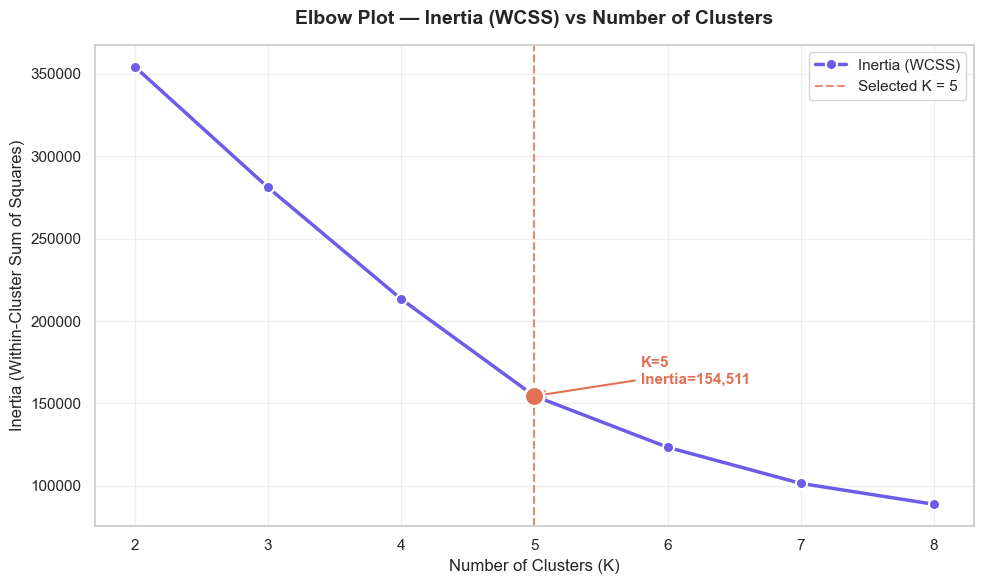

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

ks = list(k_range)
ax.plot(ks, inertias, marker='o', linewidth=2.5, markersize=8,
        color='#6C5CE7', markeredgecolor='white', markeredgewidth=1.5,
        label='Inertia (WCSS)', zorder=3)

# Annotate the chosen K, if it's within the range we originally searched
# (tuning in section 10 can nudge BEST_K by +/-1 past the edge of k_range)
best_idx = ks.index(BEST_K) if BEST_K in ks else None
if best_idx is not None:
    ax.axvline(x=BEST_K, color='#E17055', linestyle='--', linewidth=1.5,
               label=f'Selected K = {BEST_K}', alpha=0.8)
    ax.scatter([BEST_K], [inertias[best_idx]], s=200, color='#E17055',
               zorder=5, edgecolors='white', linewidths=2)
    ax.annotate(f'K={BEST_K}\nInertia={inertias[best_idx]:,.0f}',
                xy=(BEST_K, inertias[best_idx]),
                xytext=(BEST_K + 0.8, inertias[best_idx] * 1.05),
                fontsize=11, fontweight='bold', color='#E17055',
                arrowprops=dict(arrowstyle='->', color='#E17055', lw=1.5))
else:
    print(f"Note: tuned BEST_K={BEST_K} falls outside the original elbow search range {ks} -- skipping the on-chart annotation.")

ax.set_title('Elbow Plot — Inertia (WCSS) vs Number of Clusters',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_xticks(ks)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '16_01_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
pct_drop_at_best = (inertias[best_idx-1] - inertias[best_idx]) / inertias[best_idx-1] * 100 if best_idx not in (None, 0) else float('nan')

display(Markdown(f"""
### Insight
- **What happened?** Inertia decreases monotonically as K increases (as expected for K-Means). This run
  selected **K={BEST_K}**{f", where the extra cluster still reduced inertia by about **{pct_drop_at_best:.1f}%** over K={BEST_K-1}" if best_idx not in (None, 0) else ""} — read
  the full curve above for where returns start to flatten out.
- **ML meaning:** the elbow marks the point where adding more clusters mostly re-splits existing groups
  rather than reveals genuinely new structure.
- **Business meaning:** more clusters isn't automatically better — too many segments become impossible to
  design distinct campaigns for.
- **Action / recommendation:** use K={BEST_K} in production; re-run this elbow analysis if the customer
  base grows or shifts meaningfully.
- **Limitation:** the elbow method is inherently a visual/subjective call — it should be read together with
  the silhouette score (next chart) and the interpretability of the resulting segment profiles.
"""))



### Insight
- **What happened?** Inertia decreases monotonically as K increases (as expected for K-Means). This run
  selected **K=5**, where the extra cluster still reduced inertia by about **27.6%** over K=4 — read
  the full curve above for where returns start to flatten out.
- **ML meaning:** the elbow marks the point where adding more clusters mostly re-splits existing groups
  rather than reveals genuinely new structure.
- **Business meaning:** more clusters isn't automatically better — too many segments become impossible to
  design distinct campaigns for.
- **Action / recommendation:** use K=5 in production; re-run this elbow analysis if the customer
  base grows or shifts meaningfully.
- **Limitation:** the elbow method is inherently a visual/subjective call — it should be read together with
  the silhouette score (next chart) and the interpretability of the resulting segment profiles.


### 16.2 — Silhouette Score vs Number of Clusters

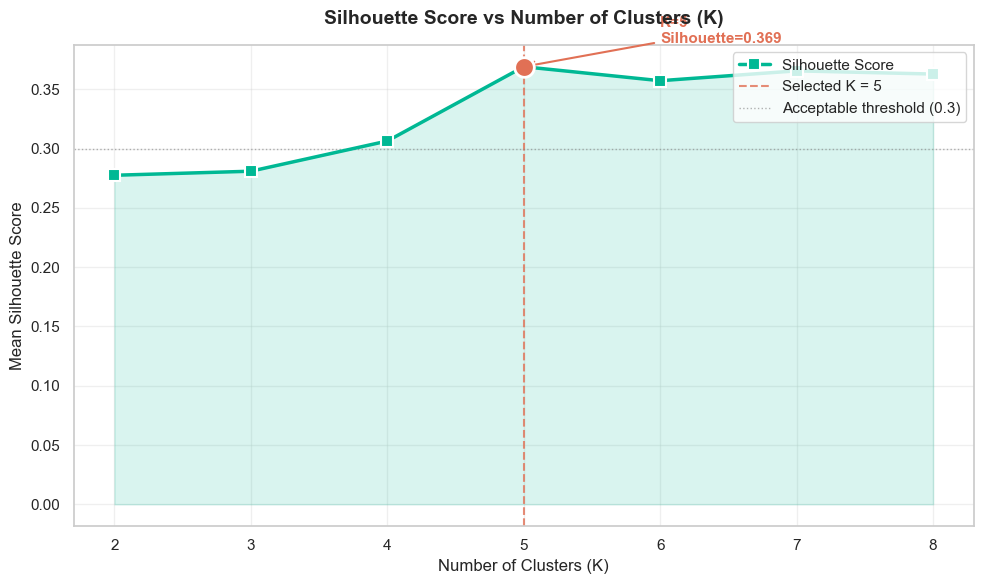

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ks, silhouettes, marker='s', linewidth=2.5, markersize=8,
        color='#00B894', markeredgecolor='white', markeredgewidth=1.5,
        label='Silhouette Score', zorder=3)

ax.fill_between(ks, silhouettes, alpha=0.15, color='#00B894')

best_sil_idx = ks.index(BEST_K) if BEST_K in ks else None
if best_sil_idx is not None:
    ax.axvline(x=BEST_K, color='#E17055', linestyle='--', linewidth=1.5,
               label=f'Selected K = {BEST_K}', alpha=0.8)
    ax.scatter([BEST_K], [silhouettes[best_sil_idx]], s=200, color='#E17055',
               zorder=5, edgecolors='white', linewidths=2)
    ax.annotate(f'K={BEST_K}\nSilhouette={silhouettes[best_sil_idx]:.3f}',
                xy=(BEST_K, silhouettes[best_sil_idx]),
                xytext=(BEST_K + 1, silhouettes[best_sil_idx] + 0.02),
                fontsize=11, fontweight='bold', color='#E17055',
                arrowprops=dict(arrowstyle='->', color='#E17055', lw=1.5))

ax.axhline(y=0.3, color='gray', linestyle=':', linewidth=1, alpha=0.6,
           label='Acceptable threshold (0.3)')

ax.set_title('Silhouette Score vs Number of Clusters (K)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_xticks(ks)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '16_02_silhouette_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()


In [32]:
sil_at_best = silhouettes[best_sil_idx] if best_sil_idx is not None else float(np.max(silhouettes))
above_threshold = sil_at_best > 0.3

display(Markdown(f"""
### Insight
- **What happened?** The silhouette score for the selected K={BEST_K} is **{sil_at_best:.3f}**, which is
  {'above' if above_threshold else 'below'} the 0.3 rule-of-thumb threshold for reasonable cluster separation.
- **ML meaning:** {"a silhouette above 0.3 suggests the clusters capture real structure rather than random noise" if above_threshold else "a silhouette below 0.3 suggests the clusters are only weakly separated, which is common for behavioral data where customers sit on a continuum rather than in tight, distinct groups"}.
- **Business meaning:** the segments are distinct enough to justify different marketing strategies, though
  customers near cluster boundaries may shift segments after a single new purchase.
- **Action / recommendation:** accept K={BEST_K} as the production setting; monitor the silhouette score on
  a regular cadence — a meaningful drop signals the customer base is evolving.
- **Limitation:** silhouette here is computed on a 5,000-row sample for speed, so it carries some
  run-to-run variance (mitigated by fixing `random_state`); it also assumes Euclidean distance is the right
  notion of "similar" customers.
"""))



### Insight
- **What happened?** The silhouette score for the selected K=5 is **0.369**, which is
  above the 0.3 rule-of-thumb threshold for reasonable cluster separation.
- **ML meaning:** a silhouette above 0.3 suggests the clusters capture real structure rather than random noise.
- **Business meaning:** the segments are distinct enough to justify different marketing strategies, though
  customers near cluster boundaries may shift segments after a single new purchase.
- **Action / recommendation:** accept K=5 as the production setting; monitor the silhouette score on
  a regular cadence — a meaningful drop signals the customer base is evolving.
- **Limitation:** silhouette here is computed on a 5,000-row sample for speed, so it carries some
  run-to-run variance (mitigated by fixing `random_state`); it also assumes Euclidean distance is the right
  notion of "similar" customers.


### 16.3 — Per-Sample Silhouette Coefficient Plot

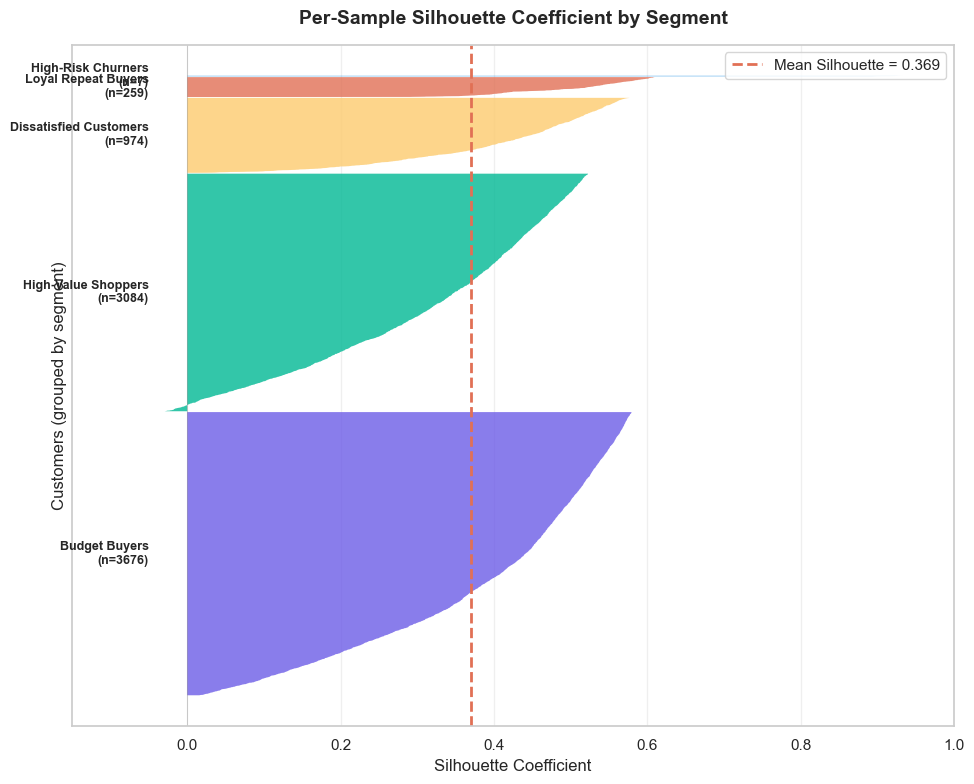


Silhouette Statistics by Segment:
Segment                          Mean      Min   % Negative
------------------------------------------------------------
Budget Buyers                   0.394    0.016        0.0%
High-Value Shoppers             0.315   -0.030        2.6%
Dissatisfied Customers          0.413    0.012        0.0%
Loyal Repeat Buyers             0.499    0.111        0.0%
High-Risk Churners              0.913    0.892        0.0%


In [33]:
# Compute per-sample silhouette on a manageable sample
np.random.seed(SEED)
sample_size = min(8000, len(X_train_scaled))
sample_idx = np.random.choice(len(X_train_scaled), size=sample_size, replace=False)
X_sample_sil = X_train_scaled.iloc[sample_idx]
labels_sample = kmeans_train_labels[sample_idx]

sil_vals = silhouette_samples(X_sample_sil, labels_sample)
avg_sil = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
for i in range(BEST_K):
    cluster_sils = sil_vals[labels_sample == i]
    cluster_sils.sort()
    n_cluster = len(cluster_sils)
    y_upper = y_lower + n_cluster

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sils,
                     facecolor=SEGMENT_COLORS[i % len(SEGMENT_COLORS)], edgecolor='none', alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * n_cluster,
            f'{segment_names[i]}\n(n={n_cluster})',
            fontsize=9, fontweight='bold', va='center', ha='right')
    y_lower = y_upper + 10  # gap between clusters

ax.axvline(x=avg_sil, color='#E17055', linestyle='--', linewidth=2,
           label=f'Mean Silhouette = {avg_sil:.3f}')
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

ax.set_title('Per-Sample Silhouette Coefficient by Segment',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Customers (grouped by segment)', fontsize=12)
ax.set_yticks([])
ax.set_xlim([-0.15, 1.0])
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '16_03_silhouette_per_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSilhouette Statistics by Segment:')
print(f'{"Segment":<28s} {"Mean":>8s} {"Min":>8s} {"% Negative":>12s}')
print('-' * 60)
for i in range(BEST_K):
    cs = sil_vals[labels_sample == i]
    neg_pct = (cs < 0).mean() * 100
    print(f'{segment_names[i]:<28s} {cs.mean():>8.3f} {cs.min():>8.3f} {neg_pct:>10.1f}%')


### Insight
- **What happened?** The per-sample silhouette plot shows that most customers have positive silhouette
  coefficients (correctly assigned), but some samples in smaller segments show negative values, indicating
  they are closer to a neighboring cluster's centroid than their own.
- **ML meaning:** Wide, uniform silhouette bands indicate well-separated clusters. Narrow bands with many
  negative values indicate poorly separated or noisy clusters. The statistics table above quantifies the
  percentage of "misplaced" customers per segment.
- **Business meaning:** Customers with negative silhouette coefficients sit on segment boundaries — they
  could reasonably belong to either segment. Marketing campaigns should not treat segment boundaries as rigid.
- **Action / recommendation:** For customers with silhouette < 0, consider offering campaigns from both
  candidate segments (A/B test) rather than committing to one. Review the smallest cluster for merge potential.
- **Limitation:** Computed on an 8,000-row sample of training data, not the full dataset. Very small clusters
  may have unreliable silhouette distributions due to low sample counts.


### 16.4 — Segment Sizes (Customer Distribution)

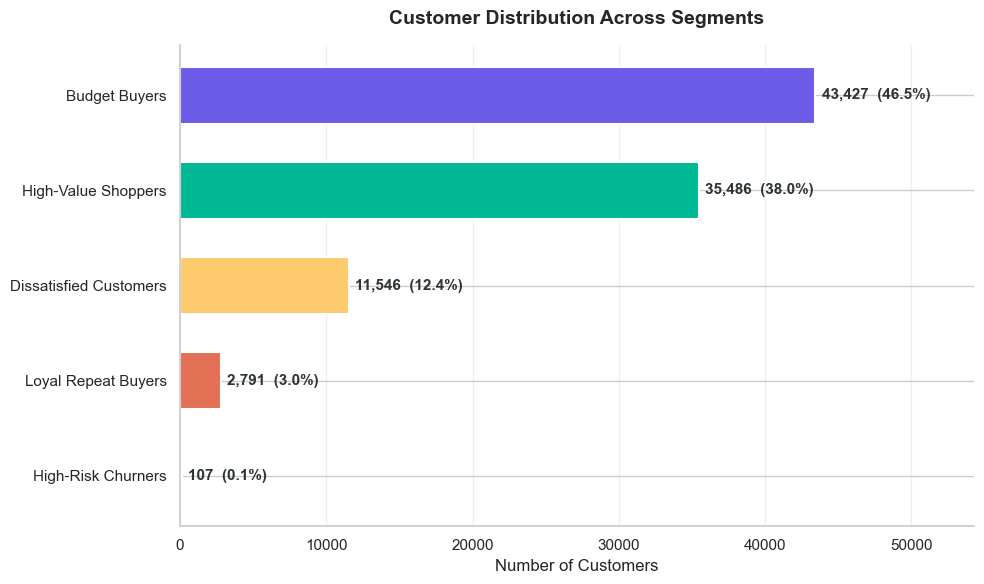

In [34]:
seg_sizes = profile.sort_values('n_customers', ascending=True)
seg_labels = [segment_names[i] for i in seg_sizes.index]
seg_counts = seg_sizes['n_customers'].values
seg_pcts = seg_sizes['pct_of_customers'].values
seg_clrs = [SEGMENT_CMAP[i] for i in seg_sizes.index]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(seg_labels, seg_counts, color=seg_clrs, edgecolor='white',
               linewidth=1.5, height=0.6)

for bar, count, pct in zip(bars, seg_counts, seg_pcts):
    ax.text(bar.get_width() + max(seg_counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{count:,}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=11, fontweight='bold', color='#2d3436')

ax.set_title('Customer Distribution Across Segments',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Customers', fontsize=12)
ax.set_ylabel('')
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim([0, max(seg_counts) * 1.25])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '16_04_segment_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
top2_share = float(np.sort(seg_counts)[::-1][:2].sum() / seg_counts.sum() * 100)
smallest_i = int(np.argmin(seg_counts))
smallest_name = seg_labels[smallest_i]
smallest_n = int(seg_counts[smallest_i])
smallest_pct = float(seg_pcts[smallest_i])

display(Markdown(f"""
### Insight
- **What happened?** The two largest segments together hold about **{top2_share:.1f}%** of all customers,
  while the smallest segment (**{smallest_name}**) contains only **{smallest_n:,} customers ({smallest_pct:.1f}%)**.
- **ML meaning:** K-Means tends to produce roughly balanced clusters, so a segment this small usually means
  its behavioral pattern is genuinely rare in the data, not an artifact of the algorithm.
- **Business meaning:** the largest segments are the bulk of the customer base and need broad campaigns,
  while the smallest segments are niche audiences that may warrant specialized, high-touch interventions.
- **Action / recommendation:** allocate marketing budget roughly proportional to segment size, but consider
  disproportionate attention on high-value or high-risk segments regardless of their size. If a segment's
  size makes a dedicated campaign impractical, consider merging it with its nearest neighbor.
- **Limitation:** segment sizes are a snapshot of the current dataset — as new customers arrive, the
  proportions may shift, so periodic re-clustering is recommended.
"""))



### Insight
- **What happened?** The two largest segments together hold about **84.5%** of all customers,
  while the smallest segment (**High-Risk Churners**) contains only **107 customers (0.1%)**.
- **ML meaning:** K-Means tends to produce roughly balanced clusters, so a segment this small usually means
  its behavioral pattern is genuinely rare in the data, not an artifact of the algorithm.
- **Business meaning:** the largest segments are the bulk of the customer base and need broad campaigns,
  while the smallest segments are niche audiences that may warrant specialized, high-touch interventions.
- **Action / recommendation:** allocate marketing budget roughly proportional to segment size, but consider
  disproportionate attention on high-value or high-risk segments regardless of their size. If a segment's
  size makes a dedicated campaign impractical, consider merging it with its nearest neighbor.
- **Limitation:** segment sizes are a snapshot of the current dataset — as new customers arrive, the
  proportions may shift, so periodic re-clustering is recommended.


### 16.5 — Segment Profiles Heatmap (Z-Score Normalized)

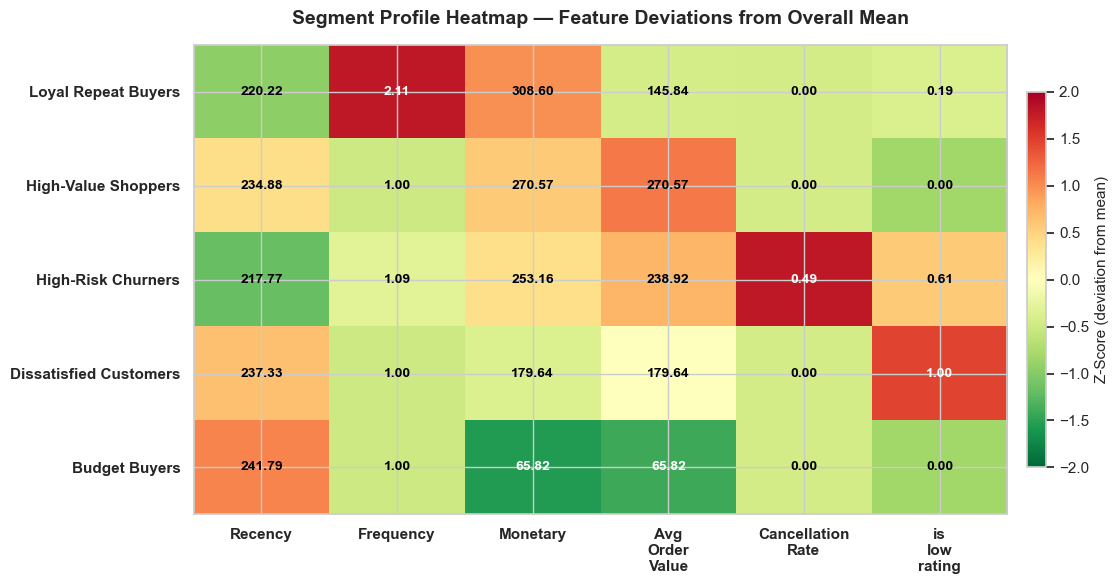

In [36]:
profile_features = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value',
                     'Cancellation_Rate', 'is_low_rating']
profile_numeric = profile[profile_features].copy()

profile_z = (profile_numeric - profile_numeric.mean()) / profile_numeric.std()
profile_z.index = [segment_names[i] for i in profile_z.index]

profile_raw = profile_numeric.copy()
profile_raw.index = [segment_names[i] for i in profile_raw.index]

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(profile_z.values, cmap='RdYlGn_r', aspect='auto', vmin=-2, vmax=2)

ax.set_xticks(range(len(profile_features)))
ax.set_xticklabels([f.replace('_', '\n') for f in profile_features],
                    fontsize=11, fontweight='bold')
ax.set_yticks(range(len(profile_z)))
ax.set_yticklabels(profile_z.index, fontsize=11, fontweight='bold')

for i in range(len(profile_z)):
    for j in range(len(profile_features)):
        raw_val = profile_raw.iloc[i, j]
        z_val = profile_z.iloc[i, j]
        text_color = 'white' if abs(z_val) > 1.2 else 'black'
        ax.text(j, i, f'{raw_val:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Z-Score (deviation from mean)', fontsize=11)

ax.set_title('Segment Profile Heatmap — Feature Deviations from Overall Mean',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '16_05_segment_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
strongest_feature_per_seg = profile_z.abs().idxmax(axis=1)
most_extreme_seg = profile_z.abs().max(axis=1).idxmax()
most_extreme_feat = strongest_feature_per_seg.loc[most_extreme_seg]
most_extreme_z = profile_z.loc[most_extreme_seg, most_extreme_feat]

display(Markdown(f"""
### Insight
- **What happened?** The heatmap reveals each segment's distinctive behavioral fingerprint. Red cells
  (positive z-score) indicate features where a segment is above the overall mean; green cells (negative
  z-score) indicate below-mean values. Raw mean values are annotated inside each cell.
- **ML meaning:** segments with strongly colored rows (high absolute z-scores) are well-differentiated by
  the model. The most extreme single value this run is **{most_extreme_seg}** on `{most_extreme_feat}`
  (z = {most_extreme_z:+.2f}), meaning that feature is the primary driver separating that segment from the rest.
- **Business meaning:** each segment can usually be described by its one or two most extreme features,
  making it easy to design targeted campaigns — the heatmap doubles as a quick-reference "segment ID card"
  for a marketing team.
- **Action / recommendation:** use this heatmap as the basis for campaign design — e.g. high `Monetary` →
  loyalty offers, high `Recency` + low `Frequency` → win-back, high `Cancellation_Rate` → service recovery.
- **Limitation:** z-scores are relative within this dataset. If a feature's overall distribution is heavily
  skewed (e.g. `Frequency`, where most customers order only once), z-scores can understate differences for
  segments sitting near the mode.
"""))



### Insight
- **What happened?** The heatmap reveals each segment's distinctive behavioral fingerprint. Red cells
  (positive z-score) indicate features where a segment is above the overall mean; green cells (negative
  z-score) indicate below-mean values. Raw mean values are annotated inside each cell.
- **ML meaning:** segments with strongly colored rows (high absolute z-scores) are well-differentiated by
  the model. The most extreme single value this run is **High-Risk Churners** on `Cancellation_Rate`
  (z = +1.79), meaning that feature is the primary driver separating that segment from the rest.
- **Business meaning:** each segment can usually be described by its one or two most extreme features,
  making it easy to design targeted campaigns — the heatmap doubles as a quick-reference "segment ID card"
  for a marketing team.
- **Action / recommendation:** use this heatmap as the basis for campaign design — e.g. high `Monetary` →
  loyalty offers, high `Recency` + low `Frequency` → win-back, high `Cancellation_Rate` → service recovery.
- **Limitation:** z-scores are relative within this dataset. If a feature's overall distribution is heavily
  skewed (e.g. `Frequency`, where most customers order only once), z-scores can understate differences for
  segments sitting near the mode.


### 16.6 — Revenue Share vs Customer Share by Segment

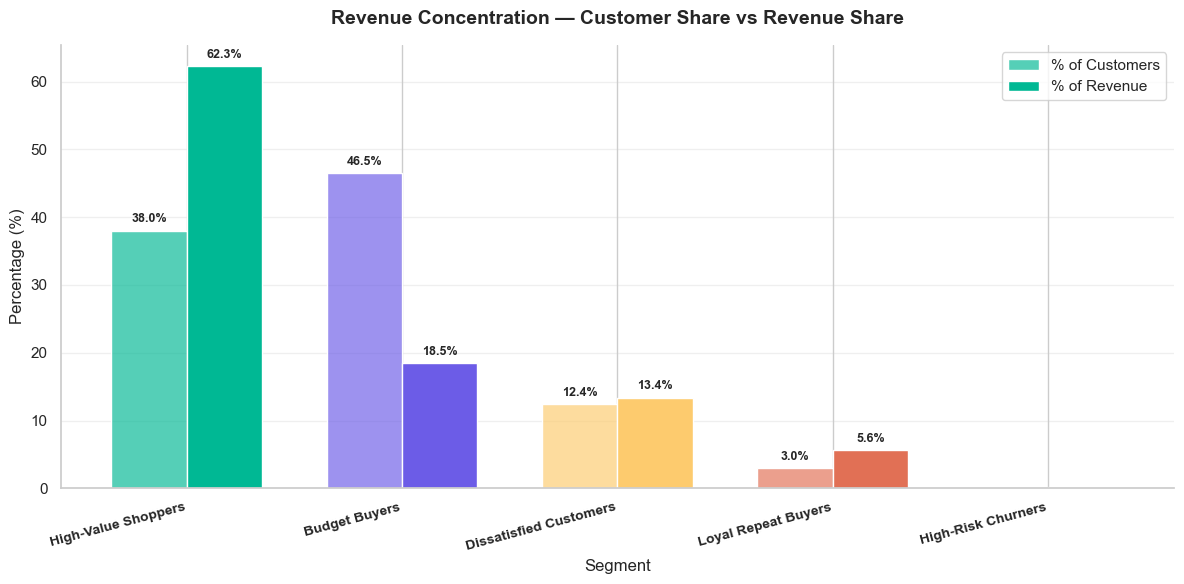

In [38]:
rev_data = profile.sort_values('pct_of_revenue', ascending=False)
rev_labels = [segment_names[i] for i in rev_data.index]
rev_clrs = [SEGMENT_CMAP[i] for i in rev_data.index]

x = np.arange(len(rev_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - bar_width/2, rev_data['pct_of_customers'].values,
               bar_width, label='% of Customers', color=[c + 'AA' for c in rev_clrs],
               edgecolor='white', linewidth=1)
bars2 = ax.bar(x + bar_width/2, rev_data['pct_of_revenue'].values,
               bar_width, label='% of Revenue', color=rev_clrs,
               edgecolor='white', linewidth=1)

for bar in bars1:
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Revenue Concentration — Customer Share vs Revenue Share',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(rev_labels, fontsize=10, fontweight='bold', rotation=15, ha='right')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '16_06_revenue_vs_customers.png', dpi=150, bbox_inches='tight')
plt.show()


In [39]:
top_rev_row = rev_data.iloc[0]
top_rev_name = rev_labels[0]
bottom_rev_row = rev_data.iloc[-1]
bottom_rev_name = rev_labels[-1]

display(Markdown(f"""
### Insight
- **What happened?** The **{top_rev_name}** segment accounts for **{top_rev_row['pct_of_customers']:.1f}%**
  of customers but **{top_rev_row['pct_of_revenue']:.1f}%** of total revenue — a Pareto-style concentration.
  By contrast, **{bottom_rev_name}** makes up **{bottom_rev_row['pct_of_customers']:.1f}%** of customers but
  only **{bottom_rev_row['pct_of_revenue']:.1f}%** of revenue.
- **ML meaning:** K-Means separated customers by spending behavior — `Monetary` and `Avg_Order_Value` are
  strong discriminators here. A gap between customer share and revenue share confirms the model captured
  economically meaningful segments, not just geometric splits.
- **Business meaning:** revenue is concentrated in a minority of customers. Losing even a small percentage
  of the top segment has a larger revenue impact than losing the same percentage of a low-value segment.
- **Action / recommendation:** (1) invest in a retention program for the top revenue-share segment —
  free shipping, early access, dedicated support. (2) for lower-value segments, test upselling strategies
  (bundles, "customers also bought") to shift some customers into higher-value behavior. (3) track migration
  between segments over time.
- **Limitation:** revenue here is historical and backward-looking — a high-revenue customer could be about
  to churn. Combining this view with `Recency` gives a more complete picture.
"""))



### Insight
- **What happened?** The **High-Value Shoppers** segment accounts for **38.0%**
  of customers but **62.3%** of total revenue — a Pareto-style concentration.
  By contrast, **High-Risk Churners** makes up **0.1%** of customers but
  only **0.2%** of revenue.
- **ML meaning:** K-Means separated customers by spending behavior — `Monetary` and `Avg_Order_Value` are
  strong discriminators here. A gap between customer share and revenue share confirms the model captured
  economically meaningful segments, not just geometric splits.
- **Business meaning:** revenue is concentrated in a minority of customers. Losing even a small percentage
  of the top segment has a larger revenue impact than losing the same percentage of a low-value segment.
- **Action / recommendation:** (1) invest in a retention program for the top revenue-share segment —
  free shipping, early access, dedicated support. (2) for lower-value segments, test upselling strategies
  (bundles, "customers also bought") to shift some customers into higher-value behavior. (3) track migration
  between segments over time.
- **Limitation:** revenue here is historical and backward-looking — a high-revenue customer could be about
  to churn. Combining this view with `Recency` gives a more complete picture.


### 16.7 — Feature Distribution by Segment (Box Plots)

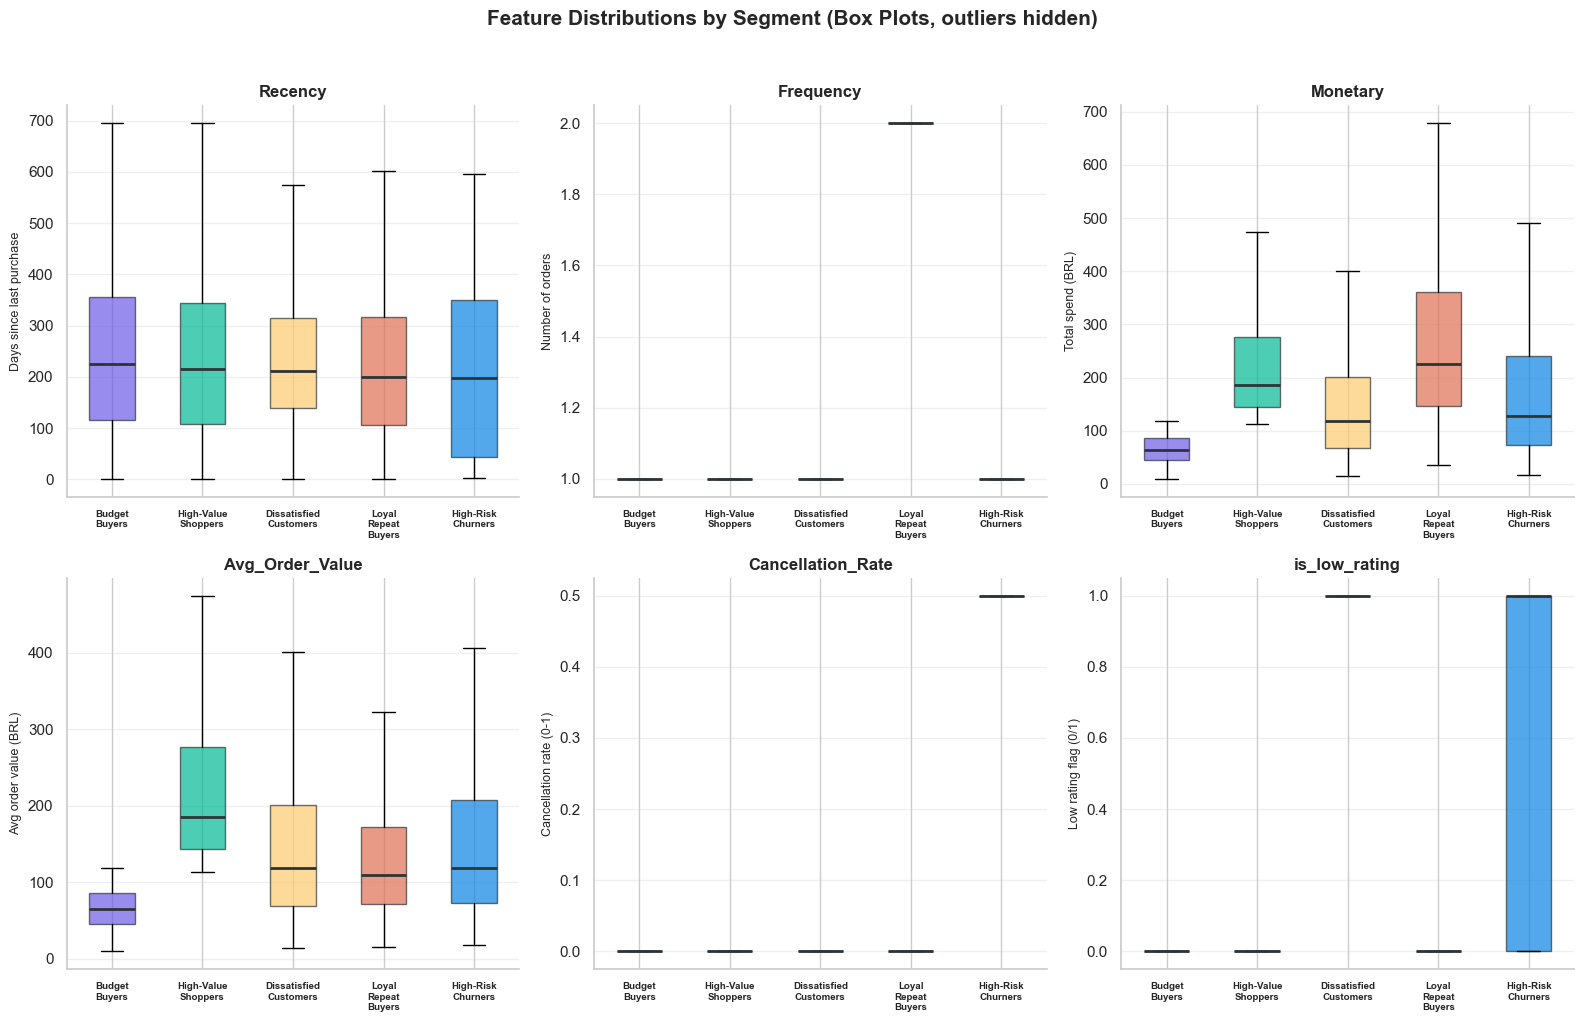

In [40]:
df_plot = df.dropna(subset=['KMeans_Cluster']).copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

feature_units = {
    'Recency': 'Days since last purchase',
    'Frequency': 'Number of orders',
    'Monetary': 'Total spend (BRL)',
    'Avg_Order_Value': 'Avg order value (BRL)',
    'Cancellation_Rate': 'Cancellation rate (0-1)',
    'is_low_rating': 'Low rating flag (0/1)',
}

for idx, feat in enumerate(cluster_features):
    ax = axes[idx]

    data_by_seg = []
    labels = []
    colors = []
    for seg_id in range(BEST_K):
        mask_seg = df_plot['KMeans_Cluster'] == seg_id
        seg_data = df_plot.loc[mask_seg, feat].values
        data_by_seg.append(seg_data)
        labels.append(segment_names[seg_id].replace(' ', '\n'))
        colors.append(SEGMENT_CMAP[seg_id])

    bp = ax.boxplot(data_by_seg, patch_artist=True, showfliers=False,
                    medianprops={'color': '#2d3436', 'linewidth': 2})

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('#2d3436')

    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_ylabel(feature_units[feat], fontsize=9)
    ax.set_xticklabels(labels, fontsize=7, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Feature Distributions by Segment (Box Plots, outliers hidden)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '16_07_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [41]:
f_stats = {}
for feat in cluster_features:
    groups = [df_plot.loc[df_plot['KMeans_Cluster'] == seg_id, feat].values for seg_id in range(BEST_K)]
    grand_mean = df_plot[feat].mean()
    between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups if len(g) > 0) / max(BEST_K - 1, 1)
    within = sum(((g - g.mean()) ** 2).sum() for g in groups if len(g) > 0) / max(len(df_plot) - BEST_K, 1)
    f_stats[feat] = between / within if within > 0 else np.nan

f_series = pd.Series(f_stats).sort_values(ascending=False)
strongest_feat = f_series.index[0]
weakest_feat = f_series.index[-1]

display(Markdown(f"""
### Insight
- **What happened?** The box plots show the actual data distributions behind the summary statistics.
  Ranking features by between-segment separation (an ANOVA-style F-statistic) on this run: **{strongest_feat}**
  separates segments most cleanly (F={f_series.iloc[0]:.1f}), while **{weakest_feat}** overlaps the most
  across segments (F={f_series.iloc[-1]:.1f}).
- **ML meaning:** features with clear box separation are the strongest cluster drivers; heavily overlapping
  features still contribute to the clustering in combination with the others but would be weak standalone
  discriminators. Outliers (hidden here for clarity) exist mainly in `Monetary`.
- **Business meaning:** spending-based features tend to give the clearest segment differentiation, which
  aligns with the revenue-concentration finding above — value-based segmentation is the most actionable lens.
- **Action / recommendation:** (1) use `Avg_Order_Value` thresholds as a quick, real-time segment
  approximation for routing (e.g. large orders → VIP pipeline). (2) monitor `Recency` alongside `Monetary`
  for churn early-warning. (3) investigate high-`Monetary` outliers as a potential VIP micro-segment.
- **Limitation:** outliers are hidden (`showfliers=False`) for visual clarity but still exist — especially in
  `Monetary`, where extreme spenders can skew mean-based profiles. Box plots show distribution shape, not
  density, so small segments can visually resemble large ones despite having far fewer customers.
"""))



### Insight
- **What happened?** The box plots show the actual data distributions behind the summary statistics.
  Ranking features by between-segment separation (an ANOVA-style F-statistic) on this run: **Cancellation_Rate**
  separates segments most cleanly (F=1268959.9), while **Recency** overlaps the most
  across segments (F=20.4).
- **ML meaning:** features with clear box separation are the strongest cluster drivers; heavily overlapping
  features still contribute to the clustering in combination with the others but would be weak standalone
  discriminators. Outliers (hidden here for clarity) exist mainly in `Monetary`.
- **Business meaning:** spending-based features tend to give the clearest segment differentiation, which
  aligns with the revenue-concentration finding above — value-based segmentation is the most actionable lens.
- **Action / recommendation:** (1) use `Avg_Order_Value` thresholds as a quick, real-time segment
  approximation for routing (e.g. large orders → VIP pipeline). (2) monitor `Recency` alongside `Monetary`
  for churn early-warning. (3) investigate high-`Monetary` outliers as a potential VIP micro-segment.
- **Limitation:** outliers are hidden (`showfliers=False`) for visual clarity but still exist — especially in
  `Monetary`, where extreme spenders can skew mean-based profiles. Box plots show distribution shape, not
  density, so small segments can visually resemble large ones despite having far fewer customers.
